# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [81]:
dataset = keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

Importelo usando pandas.

In [82]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [83]:
df = pd.read_csv(dataset, names=column_names, sep='\s+')


In [84]:
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


### Limpia los datos

Trata los missings y variables categóricas

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    398 non-null    object 
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [86]:
df['Horsepower'] = pd.to_numeric(df['Horsepower'], errors='coerce')

In [87]:
df['Horsepower'].fillna(df['Horsepower'].mean(), inplace=True)

C:\Users\Eneko\AppData\Local\Temp\ipykernel_7580\265367118.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Horsepower'].fillna(df['Horsepower'].mean(), inplace=True)


In [88]:
# Creamos la nueva columna 'Brand' tomando la primera palabra de 'Car name'
df['Brand'] = df['Car name'].str.split(expand=True, n=1)[0]


In [89]:
df.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name,Brand
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,chevrolet
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,buick
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,plymouth
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,amc
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,ford


In [90]:
# Usamos regex para capturar patrones de escritura
df['Brand'] = df['Brand'].replace(to_replace={
    r'^toy.*': 'toyota',            # Cualquier cosa que empiece por "toy" (ej. toyouta)
    r'^v[ow].*': 'volkswagen',      # Empieza por 'v' seguida de 'o' o 'w' (ej. vokswagen, vw)
    r'^ma[zx].*': 'mazda',          # Empieza por 'ma' y luego 'z' o 'x' (ej. maxda)
    r'^chev.*': 'chevrolet',        # Cualquier cosa que empiece por 'chev' (ej. chevy, chevroelt)
    r'^merced.*': 'mercedes'        # Para unificar mercedes-benz y mercedes
}, regex=True)


In [91]:
print(df['Brand'].unique())


['chevrolet' 'buick' 'plymouth' 'amc' 'ford' 'pontiac' 'dodge' 'toyota'
 'datsun' 'volkswagen' 'peugeot' 'audi' 'saab' 'bmw' 'hi' 'mercury' 'opel'
 'fiat' 'oldsmobile' 'chrysler' 'mazda' 'renault' 'honda' 'subaru' 'capri'
 'mercedes' 'cadillac' 'triumph' 'nissan']


### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [92]:
df.drop(columns=["Car name","Brand"],inplace=True)

In [93]:
df.shape

(398, 8)

In [94]:
train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

In [95]:
print(train.shape)
print(test.shape)

(318, 8)
(80, 8)


### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

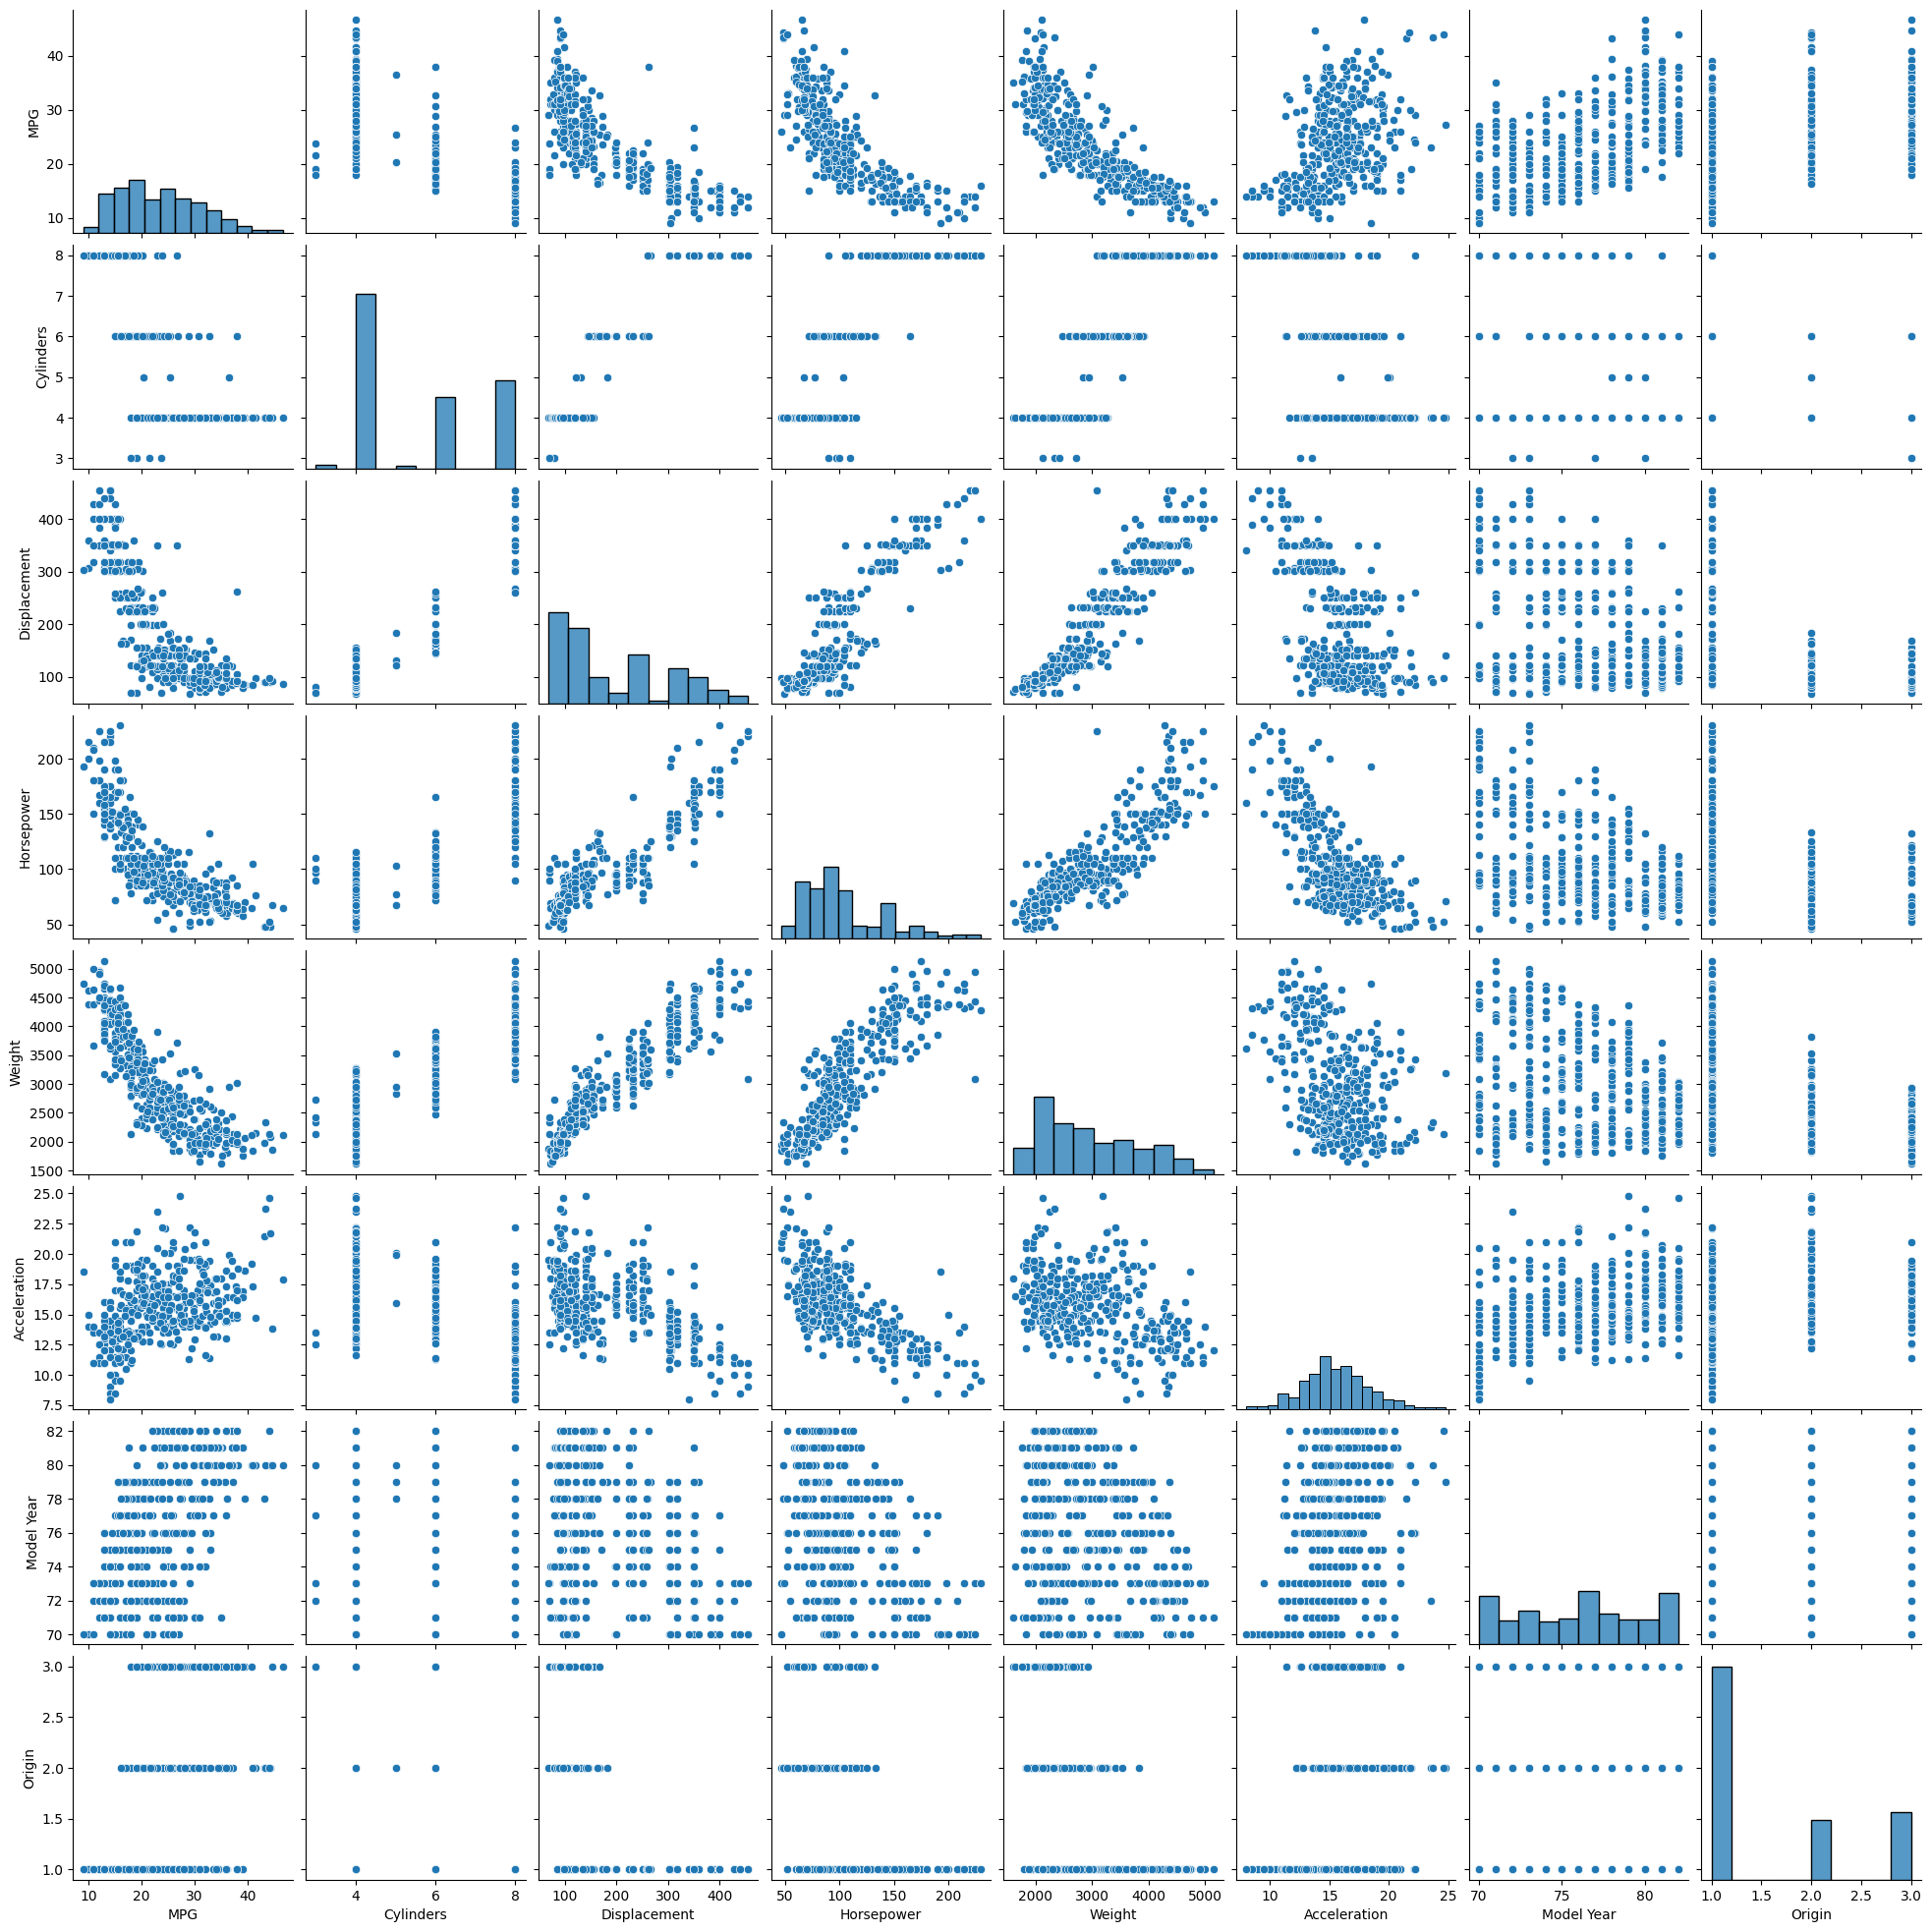

In [96]:
sns.pairplot(df)

Tambien revise las estadisticas generales:

In [97]:
df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


<Axes: >

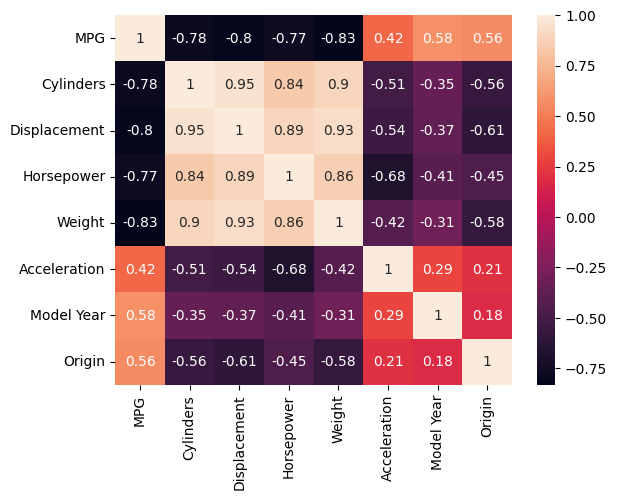

In [98]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### Separa las features del target

Separe el target de las features.

In [99]:
X_train = train.drop(columns="MPG")
X_test = test.drop(columns="MPG")
y_train = train['MPG']
y_test = test['MPG']

In [100]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(318, 7)
(80, 7)
(318,)
(80,)


### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_trian_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [102]:
X_train.shape[1:]

(7,)

In [103]:
model = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(1)
])

model.compile(
    loss="mse",
    optimizer= keras.optimizers.RMSprop(0.001),
    metrics=['mae','mse']
)

c:\Users\Eneko\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [104]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,569 (6.13 KB)

 Trainable params: 1,569 (6.13 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [105]:
X_trian_scal.shape

(318, 7)

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

In [106]:
early_stopping = keras.callbacks.EarlyStopping(patience=10)
history = model.fit(X_trian_scal, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 605.2925 - mae: 23.4003 - mse: 605.2925 - val_loss: 527.2109 - val_mae: 21.5213 - val_mse: 527.2109
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 578.7883 - mae: 22.8387 - mse: 578.7883 - val_loss: 505.8496 - val_mae: 21.0072 - val_mse: 505.8496
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 556.2054 - mae: 22.3351 - mse: 556.2054 - val_loss: 484.3503 - val_mae: 20.4578 - val_mse: 484.3503
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 532.9691 - mae: 21.7880 - mse: 532.9691 - val_loss: 462.2736 - val_mae: 19.8751 - val_mse: 462.2736
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 508.5727 - mae: 21.2063 - mse: 508.5727 - val_loss: 439.1352 - val_mae: 19.2572 - val_mse: 439.1352
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 482.6562 - mae: 20.5795 - mse: 482.6562 - val_loss: 414.8644 - val_mae: 18.5899 - val_mse: 414.8644
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 

<Axes: >

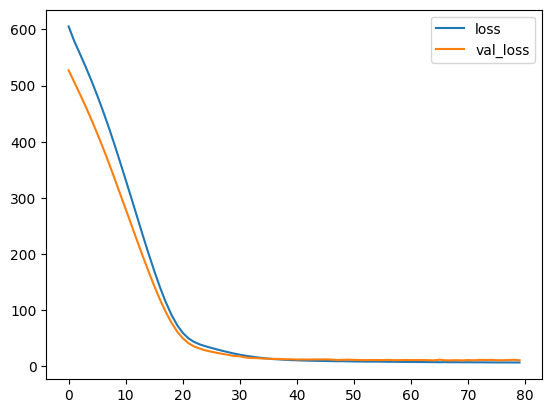

In [107]:
pd.DataFrame(history.history)[['loss','val_loss']].plot()

¿Alguna conclusión respecto a este gráfico?

Con el patience el modelo ha parado antes de los 100 epoch lo cual ha evitado overfiting y procesamiento innecesario.

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [108]:
model.evaluate(X_test_scal, y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.8943 - mae: 2.1178 - mse: 8.8943 


[8.894256591796875, 2.117770195007324, 8.894256591796875]

In [109]:
df.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.199187,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,95.000000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

In [ ]:
# Genera las predicciones para los primeros 10 registros de X_test_scal.
# Se usa X_test_scal (datos normalizados) porque el modelo fue entrenado con datos escalados.
predictions = model.predict(X_test_scal[:10])

# Mostramos el resultado
print(predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[14.386361 ],
       [14.5076685],
       [20.759153 ],
       [23.865015 ],
       [17.228598 ],
       [12.512    ],
       [19.981451 ],
       [27.767172 ],
       [25.235285 ],
       [27.245207 ]], dtype=float32)

In [119]:
y_pred_flat = y_pred.flatten()

# Creamos un pequeño DataFrame para comparar cara a cara
comparacion = pd.DataFrame({'Real': y_test, 'Predicción': y_pred_flat})
print(comparacion.head(10))


    Real  Predicción
1   15.0   14.386361
13  14.0   14.507668
20  25.0   20.759153
21  24.0   23.865015
34  16.0   17.228598
43  13.0   12.512000
48  18.0   19.981451
49  23.0   27.767172
50  28.0   25.235285
52  30.0   27.245207


Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

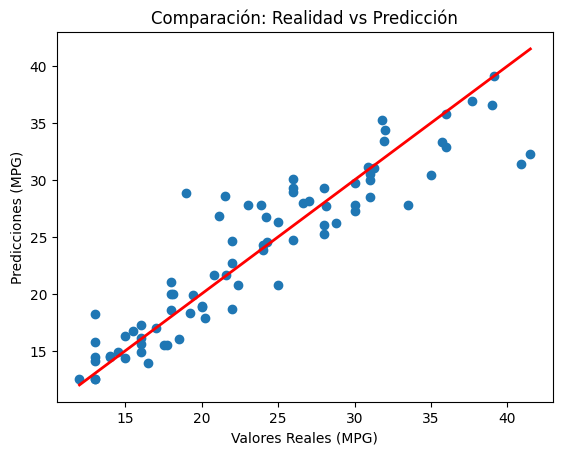

In [120]:
# Crea un gráfico de puntos comparando la realidad vs. la predicción
plt.scatter(y_test, y_pred)

# Etiquetas para entender qué estamos viendo
plt.xlabel('Valores Reales (MPG)')
plt.ylabel('Predicciones (MPG)')
plt.title('Comparación: Realidad vs Predicción')

# Dibujar una línea diagonal perfecta (opcional pero muy útil)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)

plt.show()


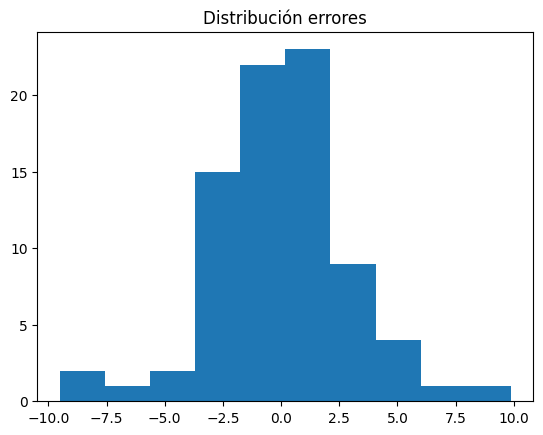

In [ ]:
# 1. Calculamos la diferencia entre la predicción y el valor real.
# .ravel() se usa para "aplanar" y_pred (convertirlo de matriz a una lista simple) 
# para que coincida con la forma de y_test y la resta sea posible.
error = y_pred.ravel() - y_test

# 2. Creamos un histograma para ver cómo se distribuyen esos errores.
# 'bins=10' divide los datos en 10 barras para agrupar los errores por magnitud.
plt.hist(error, bins=10)

# 3. Añadimos el título al gráfico para identificar qué estamos visualizando.
plt.title("Distribución errores");


No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [115]:
model.save("model.keras")

In [116]:
import_model = keras.models.load_model("model.keras")
import_model

<Sequential name=sequential_1, built=True>

## Conclusion